In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Online Retail.xlsx")

In [86]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1


In [87]:
df.shape

(392692, 10)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
 9   Cluster      392692 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(2), object(4)
memory usage: 28.5+ MB


In [89]:
round(df.describe(),2)

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Cluster
count,392692.00,392692,392692.00,392692.00,392692.00,392692.00
mean,13.12,2011-07-10 19:13:07.771892480,3.13,15287.84,22.63,1.37
min,1.00,2010-12-01 08:26:00,0.00,12346.00,0.00,0.00
25%,2.00,2011-04-07 11:12:00,1.25,13955.00,4.95,1.00
50%,6.00,2011-07-31 12:02:00,1.95,15150.00,12.45,1.00
75%,12.00,2011-10-20 12:53:00,3.75,16791.00,19.80,2.00
max,80995.00,2011-12-09 12:50:00,8142.75,18287.00,168469.60,3.00
std,180.49,NaN,22.24,1713.54,311.10,0.79


In [90]:
# check the missing value in the dataset
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Cluster        0
dtype: int64

In [91]:
df.isnull().values.any()

np.False_

In [92]:
# How to find the missing value in the percentage
round((df.isnull().sum() / len(df)) * 100,2)

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalPrice     0.0
Cluster        0.0
dtype: float64

In [93]:
# Fill missing product descriptions
df["Description"] = df["Description"].fillna("Unknown")

In [94]:
# drop rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

In [95]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Cluster        0
dtype: int64

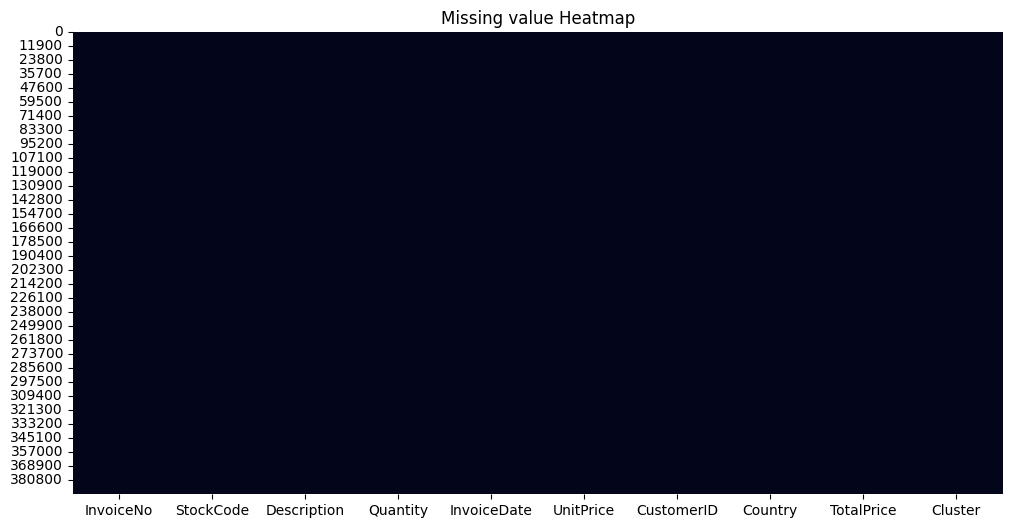

In [96]:
# Show the missing value in the visulaization 
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing value Heatmap")
plt.show()

In [97]:
# Remove all Invalid Transactions
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [98]:
# Remove Duplicate Entries
df = df.drop_duplicates()

In [99]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
Cluster                 int32
dtype: object

In [100]:
df = df.copy()
df.loc[:,"CustomerID"] = df["CustomerID"].astype(int)

In [101]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
Cluster                 int32
dtype: object

In [102]:
df = df.dropna(subset=["CustomerID"])

In [103]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [104]:
df = df.copy()
df["CustomerID"] = df["CustomerID"].astype(int)

In [105]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalPrice            float64
Cluster                 int32
dtype: object

## Featues  Engineering

Transaction-level-data -> Customer-level-featues

In [106]:
# create total price 
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [107]:
# Creat RFM Featues
import datetime as dt
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo":"nunique",
    "TotalPrice":"sum"
}).reset_index()
rfm.columns = ["CustomerID","Recency","Frequency","Monetary"]

In [108]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [109]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


Recency -> Days since last purschase
Frequency -> NO of invoices
Monetary -> total spend

=> Skewness Analysis -> Skewness means data is not normally distributed and has a long tail.
Recency ->
-> Mean > Median
-> Long tail towards higher values

-> Right-skewed distribution
Interpretation:
Most customers bought recently, but some haven’t purchased for a long time (inactive customers).

=> Frequency
->  Mean > Median
-> Very large max value

-> Highly right-skewed
Interpretation:
Most customers buy 1–2 times, but a small group buys very frequently (loyal / business customers).

=> Monetary
->  Mean >> Median
-> Extremely large max

->  Strong right-skew

Interpretation:
Few customers contribute very high revenue (VIP customers).

Conslusion:
All RFM variables are highly right-skewed, which is common in e-commerce data. This skewness must be handled before applying distance-based algorithms like K-Means.

#### Log Transformation

In [110]:
# ->log1p : 
# ->Handles zero values safely
# ->Reduces skewness
# ->Preserves relative differences
rfm_log = rfm[["Recency","Frequency","Monetary"]].apply(np.log1p)

### Standardization

In [111]:
from sklearn.preprocessing import StandardScaler

In [112]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

Mean ≈ 0
Std ≈ 1
Ready for K-Means

In [113]:
# Verify Transformation
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


#### Run K-Means Clustering

In [114]:
from sklearn.cluster import KMeans

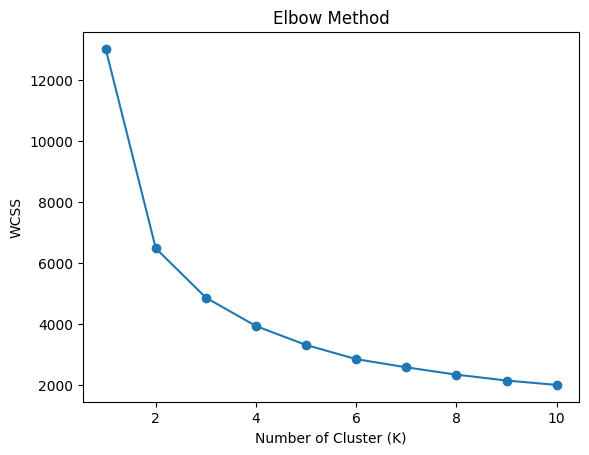

In [115]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Number of Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
| K         | WCSS Behavior          |
| --------- | ---------------------- |
| 1 → 2     | Very large drop        |
| 2 → 3     | Large drop             |
| 3 → 4     | Moderate drop          |
| **4 → 5** | Smaller drop           |
| 5+        | Very small improvement |
After K = 4, the curve flattens.

In [116]:
# Apply k-Means with K = 4
kmeans = KMeans(n_clusters = 4, random_state = 42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [117]:
rfm.groupby("Cluster").mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15417.047897,20.047897,2.008178,510.281472
1,15221.424328,11.736917,13.775106,8107.548571
2,15206.315612,66.718987,4.172996,1819.250247
3,15342.859119,186.730818,1.338994,353.811051


### Cluster 1 — Loyal / VIP Customers

Recency   ≈ 11 days (VERY recent)
Frequency ≈ 13.8 (VERY high)
Monetary  ≈ 8107 (VERY high)
------------------------------------------
Each cluster = one customer segment.
RFM logic reminder:
Recency ↓ → customer bought recently (GOOD)
Frequency ↑ → customer buys often (GOOD)
Monetary ↑ → customer spends more money (VERY GOOD)
                    Bought very recently

    --------------> Buy frequently

                    Spend a lot of money
---------------------------------------------------
Business actions

Loyalty rewards
Exclusive offers
Early access to products
VIP support
 This cluster drives maximum revenue

### Cluster 0 — New / Potential Customers

In [68]:
Recency   ≈ 20 days
Frequency ≈ 2
Monetary  ≈ 510
--------------------------
What this means
Recently active
Bought only 1–2 times
Low spending so far
------------------------
Business meaning
 New or casual buyers with growth potential
-------------------------------------------------
Business actions
Welcome offers
Upselling & cross-selling
Product recommendations

### Cluster 2 — Regular / Mid-Value Customers

In [ ]:
Recency   ≈ 67 days
Frequency ≈ 4
Monetary  ≈ 1819
-----------------------
What this means
Moderately recent
Buy occasionally
Spend decent money
----------------------------
Business meaning
 1. Stable customers, but not loyal yet
 2. Business actions
3.  Personalized offers
4. Loyalty nudges
5. Discount coupons

#### Cluster 3 — At-Risk / Lost Customers

In [ ]:
Recency   ≈ 187 days (VERY high)
Frequency ≈ 1.3
Monetary  ≈ 354
-----------------------------------
What this means
Haven’t purchased for a long time
Rarely buy
Low spending
----------------
Win-back campaigns
Big discounts
Reminder emails
If no response → stop targeting

In [ ]:
| Cluster | Segment Name                  |
| ------- | ----------------------------- |
| 0       | New / Potential Customers     |
| 1       | Loyal / VIP Customers         |
| 2       | Regular / Mid-Value Customers |
| 3       | At-Risk / Churned Customers   |


### Identify Customer Segmentation

## Scatter Plot: Recency vs Monetary

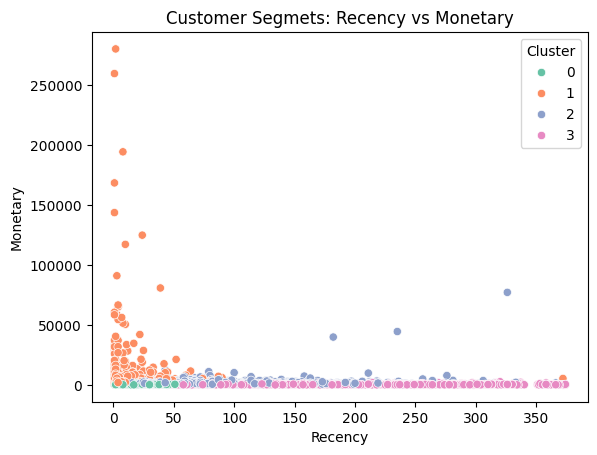

In [120]:
# Visualize the Cluster by Scatter plot
sns.scatterplot(data = rfm,x = "Recency",y="Monetary",hue="Cluster",palette="Set2")
plt.title("Customer Segmets: Recency vs Monetary")
plt.show()

In [ ]:
What the axes mean
X-axis (Recency) → Days since last purchase
Left = bought recently 
Right = long time ago 


Y-axis (Monetary) → Total money spent
Higher = more valuable customer

-------------------------------------------
What you see in the plot
Cluster 1 (orange)
Mostly on the left side (low recency)
Very high monetary values

Cluster 3 (pink)
Far on the right side (high recency)
Very low monetary values

Cluster 0 & 2 lie in between
----------------------------------------------
Simple interpretation

Customers who spent the most money also purchased recently
Customers who haven’t purchased for a long time spend very little
📌 Business insight:
Recent customers are far more valuable than inactive ones.

### Scatter Plot: Frequency vs Monetary

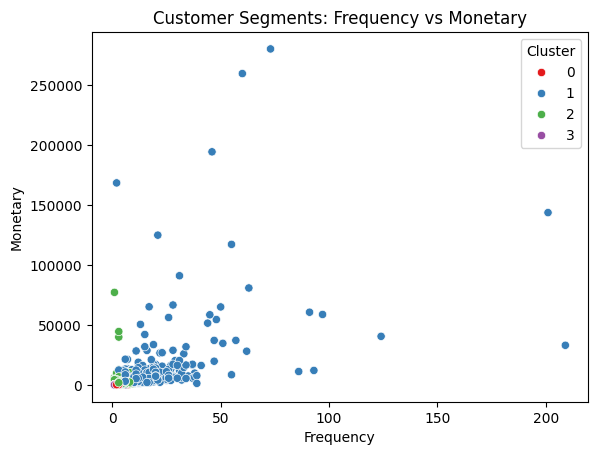

In [122]:
# Scatter Plot: Frequency vs Monetary
sns.scatterplot(data = rfm, x = "Frequency",y = "Monetary",hue = "Cluster",palette="Set1")
plt.title("Customer Segments: Frequency vs Monetary")
plt.show()

In [ ]:
What the axes mean
X-axis (Frequency) → Number of purchases
Y-axis (Monetary) → Total spending
-----------------------------------------------
What you see
Cluster 1 (blue dots)
High frequency
Very high monetary value

Cluster 3 (purple dots)
Very low frequency
Very low monetary value

Cluster 2 shows moderate behavior
--------------------------------------------
Simple interpretation
Customers who buy often also spend more
One-time buyers contribute little revenue
📌 Business insight:
Repeat customers are the backbone of revenue.

### Cluster Centroids (Standardized Values)

In [123]:
# Visualize cluster centroids
centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids, columns=["Recency","Frequency","Monetary"])
centroids_df

,Recency,Frequency,Monetary
0,-0.773756,-0.436592,-0.459282
1,-1.271529,1.662030,1.400583
2,0.081047,0.350395,0.535245
3,0.922071,-0.767027,-0.776698


In [ ]:
Consulution: 
Cluster 1:
Recency   = -1.27 (very recent)
Frequency= +1.66 (very high)
Monetary = +1.40 (very high)

How to read this 
Positive value → above average
Negative value → below average
----------------------------------
Meaning
Cluster 1 is:
More recent than average
Buys much more than average
Spends much more than average
📌 This mathematically confirms VIP / Loyal Customers

In [124]:
# Assign Cluster Labels to Original Data
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


In [125]:
df = df.merge(rfm[["CustomerID", "Cluster"]], on="CustomerID", how="left")


## Analyze Each Segment (Summary Statistics)

In [126]:
rfm.groupby("Cluster").mean()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15417.047897,20.047897,2.008178,510.281472
1,15221.424328,11.736917,13.775106,8107.548571
2,15206.315612,66.718987,4.172996,1819.250247
3,15342.859119,186.730818,1.338994,353.811051


In [ ]:
Mean  Tables
These tables help you compare clusters properly.

| Cluster | Recency | Frequency | Monetary | Meaning         |
| ------- | ------- | --------- | -------- | --------------- |
| 1       | Lowest  | Highest   | Highest  | VIP Customers   |
| 0       | Low     | Low       | Low      | New / Potential |
| 2       | Medium  | Medium    | Medium   | Regular         |
| 3       | Highest | Lowest    | Lowest   | At-Risk         |


In [127]:
rfm.groupby("Cluster").median()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,15451.0,19.0,2.0,436.940
1,15114.0,8.0,10.0,3719.100
2,15215.0,52.0,4.0,1352.750
3,15342.5,182.0,1.0,300.885


In [ ]:
Median Table (Typical customer)
Median is more reliable because it ignores extreme values.
Example:
Cluster 1 median frequency = 10
Cluster 3 median frequency = 1
📌 This shows:
A typical VIP customer buys ~10 times,
A typical at-risk customer buys only once.

In [128]:
# Standard Deviation
rfm.groupby("Cluster").std()

,CustomerID,Recency,Frequency,Monetary
Cluster,,,,
0,1730.896184,13.113585,1.010438,349.184063
1,1773.186470,17.976341,15.501405,20840.135966
2,1702.287214,53.544322,1.823165,3004.740151
3,1704.362701,99.088733,0.627803,272.142134


In [ ]:
Standard Deviation (Consistency)

High std (Cluster 1) → spending varies a lot

Low std (Cluster 3) → consistently low value

📌 Business meaning:
VIP customers include both big spenders and extremely big spenders.

In [ ]:
How to Compare Segments

Look for:

Lowest Recency → most recent buyers

Highest Frequency → loyal buyers

Highest Monetary → high spenders

## Profile the Customer Segments

In [ ]:
Cluster 1 – Loyal / VIP Customers
Characteristics

Buy frequently

Spend the most

Recently active

Action: Retain at all costs
---------------------------------------------
🔵 Cluster 0 – New / Potential Customers
Characteristics
Recently joined

Bought once or twice

Low spending

Action: Upsell & educate
=--------------------------------------------------
🟡 Cluster 2 – Regular / Mid-Value Customers
Characteristics
Average behavior

Stable but not loyal

Action: Nudge toward loyalty
======================================================
🔴 Cluster 3 – At-Risk / Churned Customers
Characteristics
Long time since last purchase

Very low engagement

Action: Win-back or stop targeting

### Visualize Differences Between Segments (Bar / Box Plots)

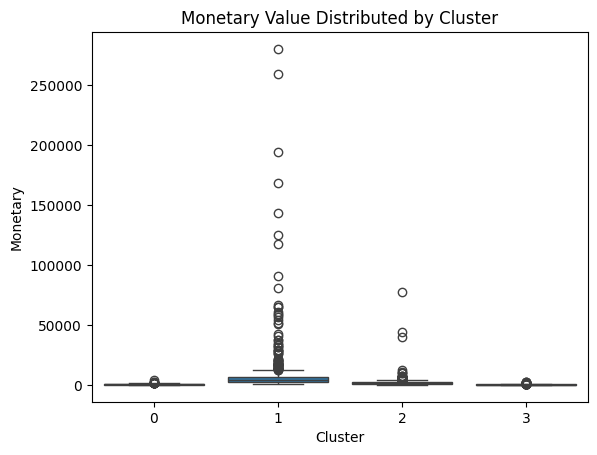

In [129]:
# Box Plot: Monetary by Cluster
sns.boxplot(data=rfm,x="Cluster",y="Monetary")
plt.title("Monetary Value Distributed by Cluster")
plt.show()

In [ ]:
What you see the above graph
Cluster 1 has:
Very high median
Many outliers (huge spenders)
Cluster 3:
Low median
Almost no outliers
 Business insight:
A small group of customers contributes disproportionately to revenue.

#### Bar Chart: Average Frequency per Cluster

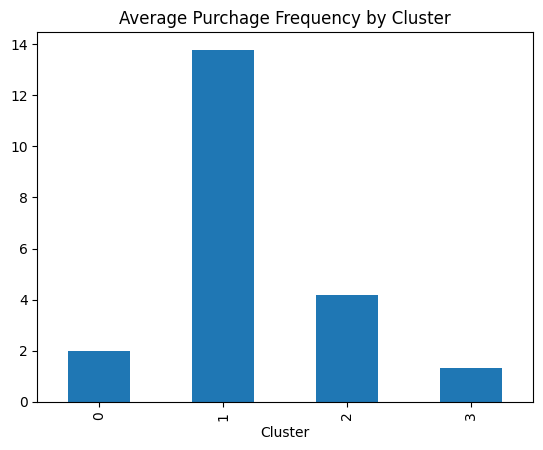

In [130]:
rfm.groupby("Cluster")["Frequency"].mean().plot(kind="bar",title="Average Purchage Frequency by Cluster")
plt.show()

In [ ]:
What it shows
Cluster 1 buys far more frequently than others
Cluster 3 buys the least
 Business insight:
If you increase purchase frequency, revenue will automatically increase.